In [43]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, average_precision_score

In [44]:
# Loading the data
df = pd.read_csv('/content/Fraud (1).csv',on_bad_lines='skip')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Here - step represents time, step = 1  → very early in the dataset timeline & step = 743  → much later in the timeline.

# **Basic EDA**

In [45]:
# Checking how many rows & columns
df.shape

(6362620, 11)

The dataset has 11 columns and 63.6 lakhs records approx.

In [46]:
# Basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [47]:
# Checking for null values
df.isnull().sum().sum()

np.int64(0)

This dataset has no null values (no need to handle null values).

In [48]:
# Checking unique values
df[['step', 'type','nameDest', 'isFraud', 'isFlaggedFraud']].nunique()

,0
step,743
type,5
nameDest,2722362
isFraud,2
isFlaggedFraud,2


In [49]:
# Checking count of transactions for min & max step-value
print('Minimum & maximum value of step-column - ', df['step'].min()," & ", df['step'].max())
df[(df['step']==1) | (df['step']==743)]['step'].value_counts()

Minimum & maximum value of step-column -  1  &  743


,count
step,
1,2708
743,8


In [50]:
# Checking count  of transactions for different types of payments
df['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [51]:
# checking count of fraud transactions
df['isFraud'].value_counts().reset_index()

,isFraud,count
0,0,6354407
1,1,8213


The dataset is of type class-imbalance.

## **Amount-based frauds**

<Axes: xlabel='isFraud', ylabel='amount'>

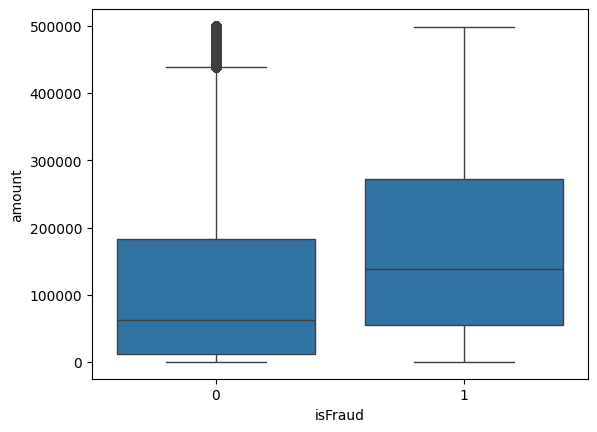

In [52]:
# Boxplot for amount of transactions
sns.boxplot(df[df['amount']<=500000], x='isFraud', y='amount')

This shows higher median for fraud transactions. Fraud is occuring for higher amounts.

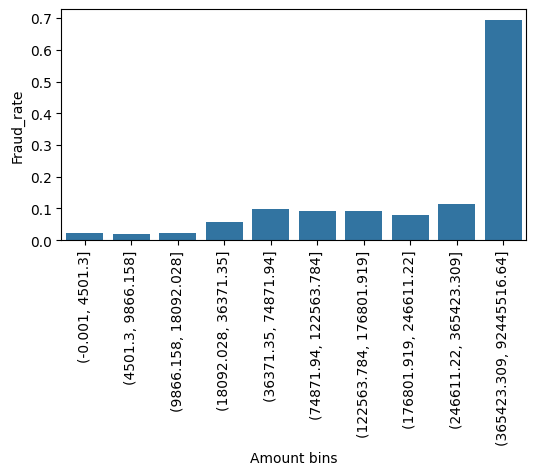

In [53]:
# Showing fraud-rates for different amount-ranges
df['amount_bin'] = pd.qcut(df['amount'], q=10, duplicates='drop')

fraud_rate = (df.groupby('amount_bin')['isFraud'].mean())*100

plt.figure(figsize=(6,3))
sns.barplot(fraud_rate)
plt.xticks(rotation=90)
plt.ylabel('Fraud_rate')
plt.xlabel('Amount bins')
plt.show()



This analysis shows that higher transaction amounts are linked to higher fraud risk, especially in larger transaction-value groups.

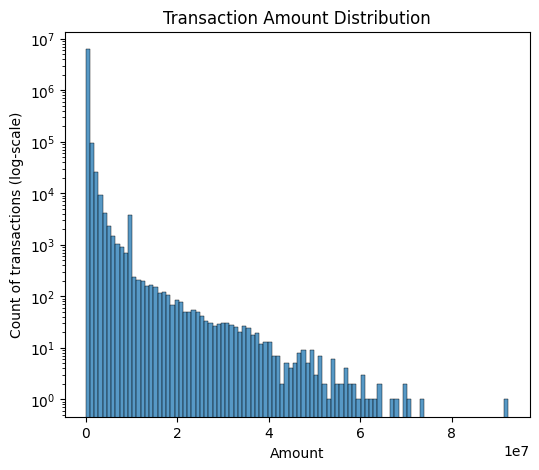

In [54]:
# Histogram-graph for transaction-amounts

plt.figure(figsize=(6,5))
sns.histplot(df['amount'],bins=100)
plt.yscale('log')
plt.ylabel('Count of transactions (log-scale)')
plt.xlabel('Amount')
plt.title('Transaction Amount Distribution')
plt.show()


*   Most transactions are concentrated at low transaction amounts.
*   The distribution is highly right-skewed, meaning a large number of transactions are small, while only a few transactions have very high amounts.
*   As transaction amount increases, the number of transactions drops sharply.
*   The y-axis is on a log scale, which means the difference between low-value and high-value transaction counts is very large.
*   There are very few transactions above around ₹4 crore–₹5 crore, but some extreme high-value transactions go close to ₹9 crore.

In [55]:
df['log_amount'] = np.log1p(df['amount'])

p99 = df['amount'].quantile(0.99)
df['is_high_amount']= (df['amount']>p99).astype(int)

df['is_high_amount'].value_counts()

,count
is_high_amount,
0,6298993
1,63627


is_high_amount identifies transactions in the top 1% by amount, helping capture unusually large transactions that are more likely to be linked with fraud, without removing any original data.

## **Undestanding Frauds**

In [56]:
# Understanding frauds - count of total & fraud transactions and also their %age

total_trnxs = len(df)
fraud_trnxs = df['isFraud'].sum()
fraud_rate = fraud_trnxs/total_trnxs
fraud_pct = round(fraud_rate *100,3)
flagged_pct = round(df['isFlaggedFraud'].sum()*100/total_trnxs,4)

print(f'Total transactions: {total_trnxs}')
print(f'Fraud transactions: {fraud_trnxs}')

print(f'Percentage of Fraud transactions: {fraud_pct} %')
print(f'Percentage of Flagged Fraud transactions: {flagged_pct} %')

Total transactions: 6362620
Fraud transactions: 8213
Percentage of Fraud transactions: 0.129 %
Percentage of Flagged Fraud transactions: 0.0003 %


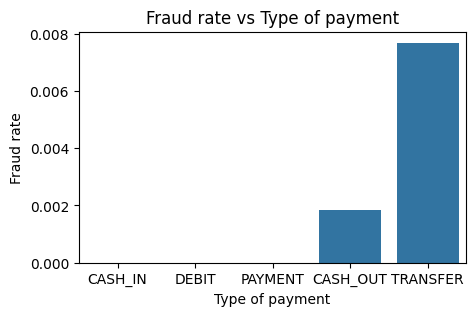

In [57]:
# Finding which type of payment has more fraud rate
a = df.groupby('type')['isFraud'].mean().sort_values(ascending=True).reset_index()
plt.figure(figsize=(5,3))
sns.barplot(a, x='type',y='isFraud')
plt.xlabel('Type of payment')
plt.ylabel('Fraud rate')
plt.title('Fraud rate vs Type of payment')
plt.show()

Only about 0.13% of transactions are actually fraudulent, but the current rule-based system flags fewer than 0.001%. This means most fraud is missed, so a machine learning approach is needed.

##**Time based overview**

In [58]:
# Calculating fraud-rates at different hours of the day
df['hour'] = df['step'] % 24
hourly_stats = df.groupby('hour').agg( total_tranxs =('isFraud','count'),
                                       fraud_tranxs=('isFraud','sum'),
                                       Fraud_rate =('isFraud','mean')  ).reset_index()
hourly_stats.head()

,hour,total_tranxs,fraud_tranxs,Fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


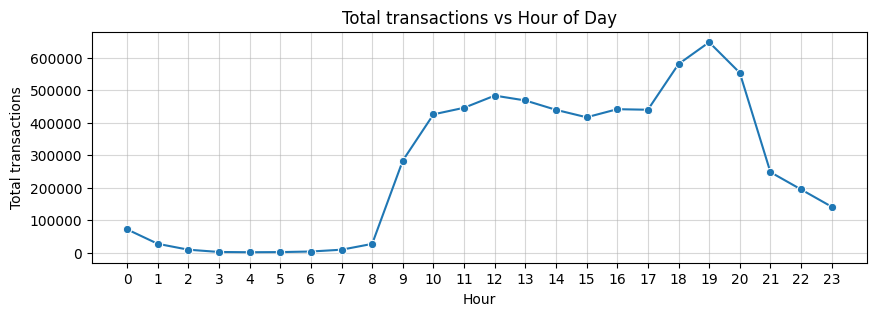

In [59]:
# Graph of total no. of transactions for different hour of the day
plt.figure(figsize=(10,3))
sns.lineplot(hourly_stats[['hour','total_tranxs']],x='hour',y='total_tranxs',marker='o')
plt.xlabel('Hour')
plt.xticks(range(0,24))
plt.ylabel('Total transactions')
plt.title('Total transactions vs Hour of Day')
plt.grid(alpha=0.5)
plt.show()

*   Transaction volume is very low during late night and early morning, especially from 2 AM to 6 AM.
*   Transactions start increasing from 8 AM, with a sharp jump around 9 AM, showing the beginning of active business/user activity hours.
*   From 10 AM to 5 PM, transaction volume stays consistently high, mostly between 4 lakh to 5 lakh transactions.
*   The highest transaction activity happens in the evening, especially between 6 PM and 8 PM.
*   The peak is at 7 PM, with around 6.5 lakh transactions, making it the busiest hour of the day.
*   After 8 PM, transaction volume drops sharply, showing reduced user activity at night.

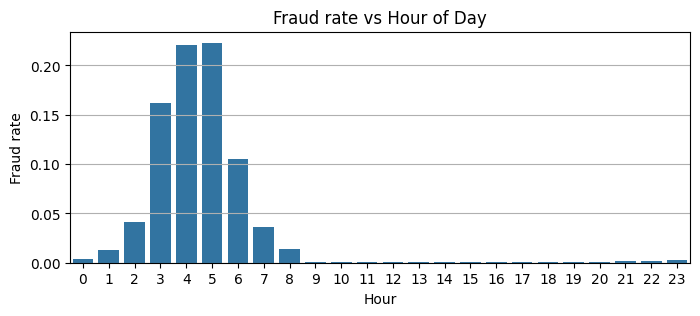

In [60]:
# Graph for fraud-rate vs hour-of-the-day
plt.figure(figsize=(8,3))
sns.barplot(hourly_stats[['hour','Fraud_rate']],x='hour',y='Fraud_rate')
plt.xlabel('Hour')
plt.ylabel('Fraud rate')
plt.title('Fraud rate vs Hour of Day')
plt.grid(axis='y')
plt.show()

*   Fraud rate is very low during most daytime and evening hours, especially from 9 AM to 11 PM.
*   Fraud risk increases sharply during the early morning hours, mainly between 3 AM and 6 AM.
*   The highest fraud rate occurs around 4 AM and 5 AM, where fraud rate is above 20%.
*   Around 3 AM, fraud rate is also high, around 16%.
*   After 6 AM, fraud rate drops quickly and becomes very low from 8 AM onward.
*   This pattern suggests that although total transaction volume is low at night, the fraud probability is much higher during late-night/early-morning hours.

##**Day & Night behaviour**

In [61]:
# Checking no. of frauds for day & night
df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype('int')

df_day_night =df.groupby('is_night')['isFraud'].mean().rename({0:'Day', 1:'Night'})
df_day_night.head()

,isFraud
is_night,
Day,0.000937
Night,0.005954


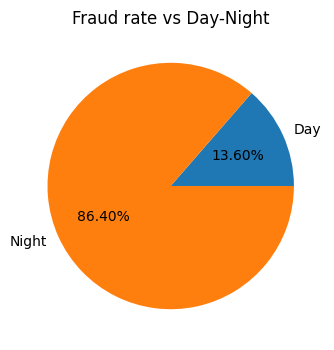

In [62]:
# Pie-chart for showing % of fraud-transactions for day & night
plt.figure(figsize=(10,4))
plt.pie(df_day_night,autopct='%1.2f%%',labels=df_day_night.index)
plt.title('Fraud rate vs Day-Night')
plt.show()

*   Fraud is much higher during night hours, contributing around 86.4%.
*   Daytime fraud is much lower, around 13.6%.
*   This shows that night-time transactions are significantly riskier compared with day-time transactions.
*   The result matches the earlier hourly fraud chart, where fraud rates were highest during early morning hours like 3 AM–6 AM.
*   Day/Night flag can be an important feature for fraud detection models.

## **Coorelation**

<Axes: >

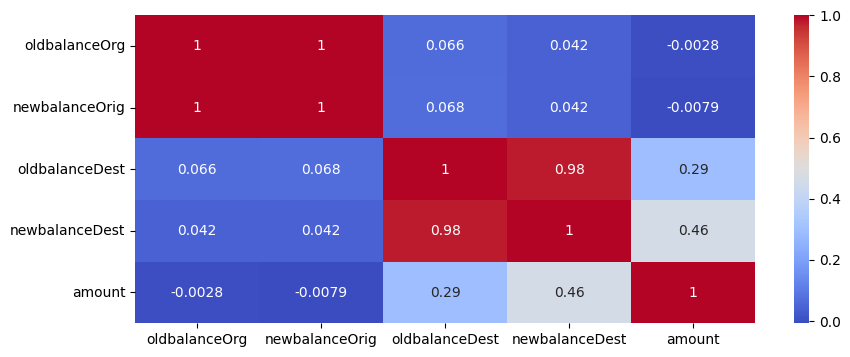

In [63]:
# Checking co-relation for numeric columns
plt.figure(figsize=(10,4))

corr= df[['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','amount']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')

This shows multi-collinearity between pre & post transactions balances indicating redundancy. To remove this issue, balance-difference features will be engineered & redundent variables will be removed. This will improve the model stability.

## **Feature Engineering & Data cleaning**

In [64]:
# Calculating new features - Balance-differences
df['Org_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['Dest_diff'] = df['newbalanceDest'] -df['oldbalanceDest']

# Feature reduction
df = df.drop(columns=['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'])

In [65]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'isFlaggedFraud', 'amount_bin', 'log_amount', 'is_high_amount', 'hour',
       'is_night', 'Org_diff', 'Dest_diff'],
      dtype='object')

In [66]:
# Dropping of columns which are not required
df.drop(columns=['amount_bin'],inplace=True)

In [67]:
# Filling null value with 0
df.fillna(0, inplace=True)

In [68]:
# Label-encoding for 'type' column
le=LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])
df.drop(columns=['nameOrig','nameDest','type'],axis=1,inplace=True)

## **Model training & Evaluation**

In [69]:
# Preparation for model training
x = df.drop(columns=['isFraud','isFlaggedFraud'])
y = df['isFraud'].values

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y, random_state=42)

scaler = RobustScaler()

num_cols = x_train.select_dtypes(include=np.number).columns
scaler.fit(x_train[num_cols])

x_train[num_cols] = scaler.transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [70]:
# Defining 3 Models & fitting them
models= {}

# Logistic Regression
print('Training Logistic Regression model (fast mode)')
lr = LogisticRegression(max_iter=300, solver='lbfgs', class_weight='balanced', n_jobs=-1)

lr.fit(x_train, y_train)
models['LogisticRegression'] = lr
print('Logistic_regression model trained')

# Random Forest
print('Training Random Forest model (optimized)')
rf = RandomForestClassifier(n_estimators=50, max_depth=12, min_samples_leaf=100, class_weight='balanced', n_jobs=-1, random_state=42)

rf.fit(x_train, y_train)
models['RandomForest'] = rf
print('Random Forest model trained')

# XgBoost
print('Training XgBoost model (fast_hist)')

scale_pos = (y_train==0).sum()/(y_train==1).sum()

xgb = XGBClassifier(n_estimators=100, max_depth=6,
                   learning_rate=0.1, subsample=0.8,
                   colsample_bytree=0.8, eval_metric='logloss',
                   scale_pos_weight=scale_pos, tree_method='hist',
                   n_jobs=-1)

xgb.fit(x_train, y_train)
models['XgBoost'] = xgb
print('XgBoost model trained')

Training Logistic Regression model (fast mode)
Logistic_regression model trained
Training Random Forest model (optimized)
Random Forest model trained
Training XgBoost model (fast_hist)
XgBoost model trained


In [71]:
# Results for 3 models

Results = []

for name,model in models.items():
  if hasattr(model, 'predict_proba'):
    scores = model.predict_proba(x_test)[:,1]
  else:
    scores = model.decision_function(x_test)

  print('/n',name)
  print(classification_report((y_test), (scores>0.5).astype(int)))

  Results.append({'model':name, 'roc_auc': roc_auc_score(y_test,scores), 'auprc':average_precision_score(y_test,scores) })

pd.DataFrame(Results).sort_values('auprc', ascending=False)

/n LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.89      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.93      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

/n RandomForest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.07      0.96      0.13      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524

/n XgBoost
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.97      0.11      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.55   1272524
weighted avg       1.00  

,model,roc_auc,auprc
2,XgBoost,0.998054,0.875526
1,RandomForest,0.997635,0.841389
0,LogisticRegression,0.977524,0.550562


**1. Logistic Regression catches fraud well but creates too many false alerts**
* Logistic Regression has 89% recall for fraud, meaning it catches most fraud cases.
* However, fraud precision is only 3%, which means most transactions flagged as fraud are actually not fraud.

**2. Random Forest performs much better**
* Random Forest has 99% fraud recall, so it detects almost all fraud cases.
* Its fraud precision improves to 18%, meaning around 1 out of 5–6 flagged transactions is actually fraud.

**3. XGBoost is the best-performing model**
* XGBoost is catching almost all fraud cases and gives the best fraud-ranking performance.

XGBoost is the best model for this fraud-detection problem. It captures almost all fraudulent transactions and gives the highest AUPRC score, making it the most reliable model for ranking high-risk transactions. However, the threshold should be adjusted based on business needs to balance fraud detection and false positives.

## **Tuning the threshold**

In [72]:
model = models['XgBoost']
y_scores = model.predict_proba(x_test)[:,1]
precision, recall, threshold = precision_recall_curve(y_test, y_scores)

candidates = [(t,p,r) for t,p,r in zip(threshold, precision[:-1], recall[:-1]) if r>=0.9]

best_t, best_p, best_r = max(candidates, key=lambda x:x[1])

print('Best threshold: ',round(best_t,3))
print('Best precision: ',round(best_p,3))
print('Best recall: ',round(best_r,3))


Best threshold:  0.913
Best precision:  0.339
Best recall:  0.9


After threshold optimization, this model can detect fraud transaction when probability exceeds 0.91. This achieves 91% recall.

## **Fine tuning the model**

In [73]:
# Fine-tuning XGBoost model
xgb_tuned = XGBClassifier(n_estimators=200, max_depth=4,
                          learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8,
                          eval_metric='logloss',
                          min_child_weight = 50,
                          scale_pos_weight=scale_pos, tree_method='hist',
                          n_jobs=-1)

xgb_tuned.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=50, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [74]:
# Fine-tuning Random-forest model
rf_tuned = RandomForestClassifier(n_estimators=100, max_depth=10,
                                  min_samples_leaf=200, min_samples_split=500,
                                  class_weight='balanced',
                                  n_jobs=-1, random_state=42)

rf_tuned.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=200, min_samples_split=500, n_jobs=-1,
                       random_state=42)

In [75]:
# Fine-tuning Logistic-Regression model
lr_tuned = LogisticRegression(max_iter=300, n_jobs=-1, solver='lbfgs', class_weight='balanced', C=0.3)

lr_tuned.fit(x_train, y_train)

LogisticRegression(C=0.3, class_weight='balanced', max_iter=300, n_jobs=-1)

In [76]:
# Defining function for evaluation of models
def evaluate(model, x ,y):
  scores = model.predict_proba(x)[:,1]

  return {"ROC_AUC":roc_auc_score(y,scores), "AUC_PR":average_precision_score(y,scores)}

In [77]:
# Printing the results of the models
print("XGB tuned:", evaluate(xgb_tuned,x_test,y_test))
print("rf tuned:", evaluate(rf_tuned,x_test,y_test))
print("lr tuned:", evaluate(lr_tuned,x_test,y_test))

XGB tuned: {'ROC_AUC': np.float64(0.9982141722484371), 'AUC_PR': np.float64(0.8622614125367913)}
rf tuned: {'ROC_AUC': np.float64(0.9977627404714509), 'AUC_PR': np.float64(0.8328664572203298)}
lr tuned: {'ROC_AUC': np.float64(0.9774936739612737), 'AUC_PR': np.float64(0.5504119584396517)}


XGBoost is the best model as it catches most of the frauds with fewer false alarms, while RandomForest is little worse and Logistic Regression struggles with fraud-detection.

## **Saving the fine tuned model**

In [78]:
models = {"XgBoost":xgb_tuned, "Random Forest":rf_tuned, "Logistic Regression":lr_tuned}

best_model_name = max(Results, key=lambda x:x['auprc'])['model']
print(best_model_name)


XgBoost


In [79]:
best_model = models[best_model_name]

best_model_artifact = { "model_name":best_model_name,
                    "model":best_model,
                     "threshold":best_t,
                     "features":x_train.columns.tolist()}

In [80]:
# Saving the pickle file
import joblib
joblib.dump(best_model_artifact, "Bank_fraud_detection.pkl")

print("Saved the model ",best_model_name)
print("decision threshold ",best_t)

Saved the model  XgBoost
decision threshold  0.91314894


## **Testing**

In [81]:
# Loading & saving model artifact

artifact = joblib.load("Bank_fraud_detection.pkl")
model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Prdiction on test data
y_scores = model.predict_proba(x_test[features])[:,1]
y_pred = (y_scores >= threshold).astype('int')

# Confusion metrix
cm =confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Summary table
summary = pd.DataFrame({"count":[tp, fn, fp, tn]},
                       index=["Correctly detected fraud (TP)",
                              "Missed fraud (FN)",
                              "False alarms (FP)",
                              "Correct non-fraud (TN)"])

print(summary)

# QUick fraud recall check
print("Fraud recall: ",round(tp/(tp+fn),3))
print("Fraud precision: ",round(tp/(tp+fp),3))

                                 count
Correctly detected fraud (TP)     1471
Missed fraud (FN)                  172
False alarms (FP)                 3361
Correct non-fraud (TN)         1267520
Fraud recall:  0.895
Fraud precision:  0.304


At the optimized threshold, the model detects around 90% of fraudulent transactions with about 29% precision, meaning nearly one out of every three flagged transactions is actually fraud. This helps reduce false positives while still capturing most fraud cases, making the model suitable for production use. Fewer false alerts can lower operational effort, improve customer experience, and support safer transactions.